Plot saved as fft_time_vs_size.png


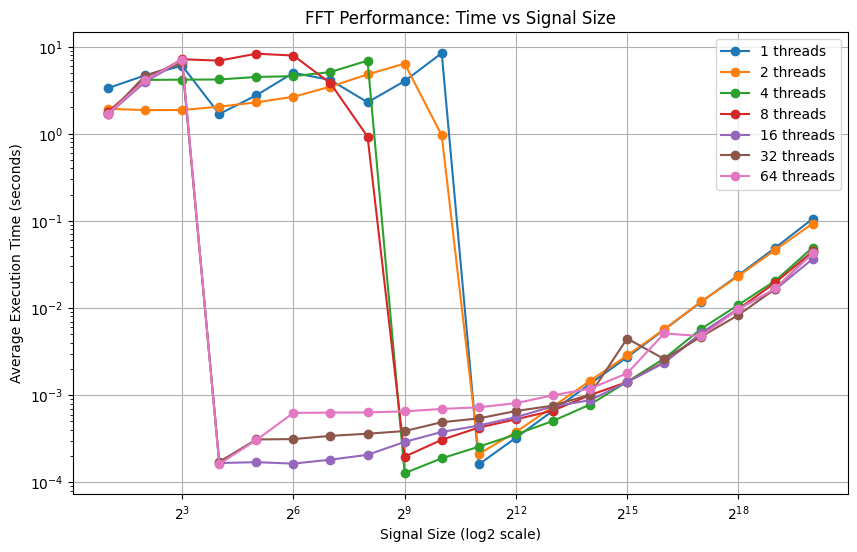

In [1]:
import csv
import matplotlib.pyplot as plt

CSV_FILE = "fft_results.csv"

# Store data: {threads: [(size, avg_time), ...]}
data = {}

# ----------------------------
# Read CSV
# ----------------------------
with open(CSV_FILE, "r") as file:
    reader = csv.DictReader(file)
    
    for row in reader:
        size = int(row["Signal_Size"])
        threads = int(row["Threads"])
        time = float(row["Avg_Time"])

        if threads not in data:
            data[threads] = []
        
        data[threads].append((size, time))

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 6))

for threads, values in sorted(data.items()):
    values.sort()  # sort by signal size
    sizes = [v[0] for v in values]
    times = [v[1] for v in values]

    plt.plot(sizes, times, marker='o', label=f"{threads} threads")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Signal Size (log2 scale)")
plt.ylabel("Average Execution Time (seconds)")
plt.title("FFT Performance: Time vs Signal Size")
plt.legend()
plt.grid(True)

plt.savefig("fft_time_vs_size.png")
print("Plot saved as fft_time_vs_size.png")

# Optional (only if GUI works)
# plt.show()

In [3]:
import csv
import matplotlib.pyplot as plt
import os

CSV_FILE = "fft_results.csv"
OUTPUT_DIR = "plots_by_size"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Store data: {size: [(threads, avg_time), ...]}
data = {}

# ----------------------------
# Read CSV
# ----------------------------
with open(CSV_FILE, "r") as file:
    reader = csv.DictReader(file)
    
    for row in reader:
        if row["Avg_Time"] == "None":
            continue

        size = int(row["Signal_Size"])
        threads = int(row["Threads"])
        time = float(row["Avg_Time"])

        if size not in data:
            data[size] = []
        
        data[size].append((threads, time))

# ----------------------------
# Generate one plot per signal size
# ----------------------------
for size, values in sorted(data.items()):
    values.sort()  # sort by thread count

    threads = [v[0] for v in values]
    times = [v[1] for v in values]

    plt.figure()

    plt.plot(threads, times, marker='o')
    plt.xscale("log", base=2)
    plt.yscale("log")

    plt.xlabel("Number of Threads (log2 scale)")
    plt.ylabel("Average Execution Time (seconds)")
    plt.title(f"FFT Scaling (Signal Size = {size})")
    plt.grid(True)

    filename = f"{OUTPUT_DIR}/fft_size_{size}.png"
    plt.savefig(filename)
    plt.close()

    print(f"Saved: {filename}")

Saved: plots_by_size/fft_size_2.png
Saved: plots_by_size/fft_size_4.png
Saved: plots_by_size/fft_size_8.png
Saved: plots_by_size/fft_size_16.png
Saved: plots_by_size/fft_size_32.png
Saved: plots_by_size/fft_size_64.png
Saved: plots_by_size/fft_size_128.png
Saved: plots_by_size/fft_size_256.png
Saved: plots_by_size/fft_size_512.png
Saved: plots_by_size/fft_size_1024.png
Saved: plots_by_size/fft_size_2048.png
Saved: plots_by_size/fft_size_4096.png
Saved: plots_by_size/fft_size_8192.png
Saved: plots_by_size/fft_size_16384.png
Saved: plots_by_size/fft_size_32768.png
Saved: plots_by_size/fft_size_65536.png
Saved: plots_by_size/fft_size_131072.png
Saved: plots_by_size/fft_size_262144.png
Saved: plots_by_size/fft_size_524288.png
Saved: plots_by_size/fft_size_1048576.png
